# Notebook 03 — Entrenamiento y Evaluación de Modelos (Dataset ULB)
**TFM:** Detección de fraude — comparativa de modelos y evaluación de generalización cross-domain

**Prerrequisito:** Haber ejecutado `notebook_02_preprocesamiento.ipynb` (genera `data_splits/`)

⚠️ **Este notebook puede tardar 30–90 minutos** según el hardware. Se guardan resultados parciales en disco.

**Librerías necesarias:**
```
pip install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm joblib tqdm
```


In [1]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm joblib tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── IMPORTACIONES ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib, time, json, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, recall_score, f1_score,
    roc_auc_score, precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. Cargar particiones y configuración

In [3]:
# ── CARGA ─────────────────────────────────────────────────────────────────
X_train = pd.read_csv('data_splits/X_train.csv')
X_test  = pd.read_csv('data_splits/X_test.csv')
y_train = pd.read_csv('data_splits/y_train.csv').squeeze()
y_test  = pd.read_csv('data_splits/y_test.csv').squeeze()

with open('data_splits/config.json') as f:
    config = json.load(f)

RANDOM_SEED     = config['RANDOM_SEED']
CV_FOLDS        = config['CV_FOLDS']
ratio_neg_pos   = config['ratio_neg_pos']

print(f"X_train: {X_train.shape} | Fraudes: {y_train.sum()}")
print(f"X_test : {X_test.shape}  | Fraudes: {y_test.sum()}")


X_train: (227845, 30) | Fraudes: 394
X_test : (56962, 30)  | Fraudes: 98


## 2. Definición de modelos, resamplers e hiperparámetros

In [4]:
# ── MODELOS ───────────────────────────────────────────────────────────────
MODELS = {
    'LR': LogisticRegression(
        solver='lbfgs', max_iter=1000, class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    'DT': DecisionTreeClassifier(
        criterion='gini', class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    'RF': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_SEED
    ),
    'XGB': XGBClassifier(
        tree_method='hist', scale_pos_weight=ratio_neg_pos,
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_SEED,
        verbosity=0
    ),
    'LGBM': LGBMClassifier(
        is_unbalance=True, n_jobs=-1,
        random_state=RANDOM_SEED, verbose=-1
    )
}

# ── GRIDS DE HIPERPARÁMETROS ───────────────────────────────────────────────
PARAM_GRIDS = {
    'LR'  : {'classifier__C': [0.01, 0.1, 1, 10]},
    'DT'  : {'classifier__max_depth': [5, 8, 15, None],
              'classifier__min_samples_split': [2, 5, 10]},
    'RF'  : {'classifier__n_estimators': [100, 200],
              'classifier__max_depth': [10, 20, None],
              'classifier__max_features': ['sqrt', 'log2']},
    'XGB' : {'classifier__n_estimators': [100, 200],
              'classifier__max_depth': [3, 6],
              'classifier__learning_rate': [0.05, 0.1, 0.3]},
    'LGBM': {'classifier__n_estimators': [100, 200],
              'classifier__max_depth': [-1, 6, 10],
              'classifier__learning_rate': [0.05, 0.1],
              'classifier__num_leaves': [31, 63]}
}

RESAMPLERS = {
    'None' : None,
    'SMOTE': SMOTE(random_state=RANDOM_SEED, k_neighbors=5),
    'ADASYN': ADASYN(random_state=RANDOM_SEED, n_neighbors=5)
}

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

print(f"Modelos        : {list(MODELS.keys())}")
print(f"Resamplers     : {list(RESAMPLERS.keys())}")
print(f"Combinaciones  : {len(MODELS) * len(RESAMPLERS)}")


Modelos        : ['LR', 'DT', 'RF', 'XGB', 'LGBM']
Resamplers     : ['None', 'SMOTE', 'ADASYN']
Combinaciones  : 15


## 3. Función de evaluación

In [5]:
# ── FUNCIÓN DE EVALUACIÓN ────────────────────────────────────────────────
def evaluate_model(model, X_eval, y_eval, model_name='', strategy='',
                   t_train=0.0, t_infer=0.0):
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()
    return {
        'Modelo'         : model_name,
        'Estrategia'     : strategy,
        'AUC_PR'         : round(average_precision_score(y_eval, y_proba), 4),
        'AUC_ROC'        : round(roc_auc_score(y_eval, y_proba), 4),
        'Recall'         : round(recall_score(y_eval, y_pred), 4),
        'Precision'      : round(precision_score(y_eval, y_pred, zero_division=0), 4),
        'F1'             : round(f1_score(y_eval, y_pred), 4),
        'TP'             : int(tp), 'FP': int(fp),
        'TN'             : int(tn), 'FN': int(fn),
        'T_train_s'      : round(t_train, 3),
        'T_infer_ms_tx'  : round(t_infer * 1000 / len(X_eval), 5),
    }

print("✅ Función evaluate_model lista")


✅ Función evaluate_model lista


## 4. Entrenamiento con GridSearchCV (15 combinaciones)

In [6]:
# ── ENTRENAMIENTO PRINCIPAL ───────────────────────────────────────────────
# ⚠️  Este bloque puede tardar 30-90 minutos según el hardware
# Los resultados se guardan incrementalmente en disco

os.makedirs('resultados', exist_ok=True)
results_list   = []
best_models    = {}

print("Iniciando entrenamiento de 15 combinaciones modelo/estrategia...")
print("=" * 70)

for model_name, model in MODELS.items():
    best_models[model_name] = {}
    for strategy_name, resampler in RESAMPLERS.items():
        combo_key = f"{model_name}_{strategy_name}"
        print(f"\n▶  {model_name} + {strategy_name}")

        # Construir pipeline
        if resampler is not None:
            pipe = ImbPipeline([('resampler', resampler), ('classifier', model)])
        else:
            pipe = Pipeline([('classifier', model)])

        # GridSearchCV con validación cruzada interna
        param_grid = PARAM_GRIDS[model_name]
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring='average_precision',
            cv=skf,
            n_jobs=-1,
            refit=True,
            verbose=0
        )

        # Entrenamiento
        t0 = time.perf_counter()
        gs.fit(X_train, y_train)
        t_train = time.perf_counter() - t0

        # Inferencia sobre test
        t1 = time.perf_counter()
        _ = gs.predict(X_test)
        t_infer = time.perf_counter() - t1

        # Evaluación final sobre test
        metrics = evaluate_model(
            gs, X_test, y_test,
            model_name=model_name,
            strategy=strategy_name,
            t_train=t_train,
            t_infer=t_infer
        )
        metrics['Best_params'] = str(gs.best_params_)
        metrics['CV_AUC_PR_mean'] = round(gs.best_score_, 4)

        results_list.append(metrics)
        best_models[model_name][strategy_name] = gs.best_estimator_

        print(f"   AUC-PR (test): {metrics['AUC_PR']:.4f} | Recall: {metrics['Recall']:.4f} | "
              f"F1: {metrics['F1']:.4f} | T_train: {t_train:.1f}s")

        # Guardar el modelo
        joblib.dump(gs.best_estimator_, f"resultados/model_{combo_key}.pkl")

# Guardar tabla de resultados
results_df = pd.DataFrame(results_list)
results_df.to_csv('resultados/tabla_resultados_ulb.csv', index=False)
print("\n" + "=" * 70)
print("✅ Entrenamiento completado. Resultados guardados en resultados/")


Iniciando entrenamiento de 15 combinaciones modelo/estrategia...

▶  LR + None
   AUC-PR (test): 0.7189 | Recall: 0.9184 | F1: 0.1141 | T_train: 3.7s

▶  LR + SMOTE
   AUC-PR (test): 0.7237 | Recall: 0.9184 | F1: 0.1094 | T_train: 5.2s

▶  LR + ADASYN
   AUC-PR (test): 0.7316 | Recall: 0.9184 | F1: 0.0355 | T_train: 5.8s

▶  DT + None
   AUC-PR (test): 0.6119 | Recall: 0.7347 | F1: 0.6667 | T_train: 31.6s

▶  DT + SMOTE
   AUC-PR (test): 0.4512 | Recall: 0.8265 | F1: 0.0997 | T_train: 95.9s

▶  DT + ADASYN
   AUC-PR (test): 0.2984 | Recall: 0.7347 | F1: 0.5143 | T_train: 116.4s

▶  RF + None
   AUC-PR (test): 0.8589 | Recall: 0.7551 | F1: 0.8457 | T_train: 527.1s

▶  RF + SMOTE
   AUC-PR (test): 0.8756 | Recall: 0.8367 | F1: 0.8454 | T_train: 1557.6s

▶  RF + ADASYN
   AUC-PR (test): 0.8673 | Recall: 0.8061 | F1: 0.8229 | T_train: 1486.7s

▶  XGB + None
   AUC-PR (test): 0.8830 | Recall: 0.8367 | F1: 0.8586 | T_train: 18.0s

▶  XGB + SMOTE
   AUC-PR (test): 0.8433 | Recall: 0.8776 | F1

## 5. Tabla de resultados completa

In [7]:
# ── TABLA PRINCIPAL DE RESULTADOS ─────────────────────────────────────────
results_df = pd.read_csv('resultados/tabla_resultados_ulb.csv')

print("=== TABLA COMPLETA DE RESULTADOS — Dataset ULB ===")
print()
display_cols = ['Modelo','Estrategia','AUC_PR','AUC_ROC','Recall','Precision','F1',
                'TP','FN','T_train_s','T_infer_ms_tx']
print(results_df[display_cols].sort_values(['AUC_PR'], ascending=False).to_string(index=False))


=== TABLA COMPLETA DE RESULTADOS — Dataset ULB ===

Modelo Estrategia  AUC_PR  AUC_ROC  Recall  Precision     F1  TP  FN  T_train_s  T_infer_ms_tx
   XGB        NaN  0.8830   0.9601  0.8367     0.8817 0.8586  82  16     18.034        0.00021
    RF      SMOTE  0.8756   0.9673  0.8367     0.8542 0.8454  82  16   1557.634        0.00128
    RF     ADASYN  0.8673   0.9772  0.8061     0.8404 0.8229  79  19   1486.732        0.00114
    RF        NaN  0.8589   0.9572  0.7551     0.9610 0.8457  74  24    527.110        0.00108
  LGBM     ADASYN  0.8584   0.9779  0.8163     0.7921 0.8040  80  18    692.073        0.00162
   XGB     ADASYN  0.8489   0.9742  0.8367     0.5985 0.6979  82  16     35.072        0.00024
   XGB      SMOTE  0.8433   0.9743  0.8776     0.2614 0.4028  86  12     36.840        0.00025
  LGBM      SMOTE  0.8216   0.9698  0.8571     0.6942 0.7671  84  14    679.528        0.00116
    LR     ADASYN  0.7316   0.9725  0.9184     0.0181 0.0355  90   8      5.843        0.0001

In [8]:
# ── TABLA PIVOTADA POR AUC-PR ─────────────────────────────────────────────
pivot_aucpr = results_df.pivot(index='Modelo', columns='Estrategia', values='AUC_PR')
pivot_recall = results_df.pivot(index='Modelo', columns='Estrategia', values='Recall')

print("\n=== AUC-PR POR MODELO Y ESTRATEGIA ===")
print(pivot_aucpr.to_string())
print("\n=== RECALL POR MODELO Y ESTRATEGIA ===")
print(pivot_recall.to_string())

# Mejor combinación global
best_row = results_df.loc[results_df['AUC_PR'].idxmax()]
print(f"\n🏆 MEJOR COMBINACIÓN: {best_row['Modelo']} + {best_row['Estrategia']}")
print(f"   AUC-PR: {best_row['AUC_PR']} | Recall: {best_row['Recall']} | F1: {best_row['F1']}")



=== AUC-PR POR MODELO Y ESTRATEGIA ===
Estrategia     NaN  ADASYN   SMOTE
Modelo                            
DT          0.6119  0.2984  0.4512
LGBM        0.1214  0.8584  0.8216
LR          0.7189  0.7316  0.7237
RF          0.8589  0.8673  0.8756
XGB         0.8830  0.8489  0.8433

=== RECALL POR MODELO Y ESTRATEGIA ===
Estrategia     NaN  ADASYN   SMOTE
Modelo                            
DT          0.7347  0.7347  0.8265
LGBM        0.8265  0.8163  0.8571
LR          0.9184  0.9184  0.9184
RF          0.7551  0.8061  0.8367
XGB         0.8367  0.8367  0.8776

🏆 MEJOR COMBINACIÓN: XGB + nan
   AUC-PR: 0.883 | Recall: 0.8367 | F1: 0.8586


## 6. Visualizaciones de resultados

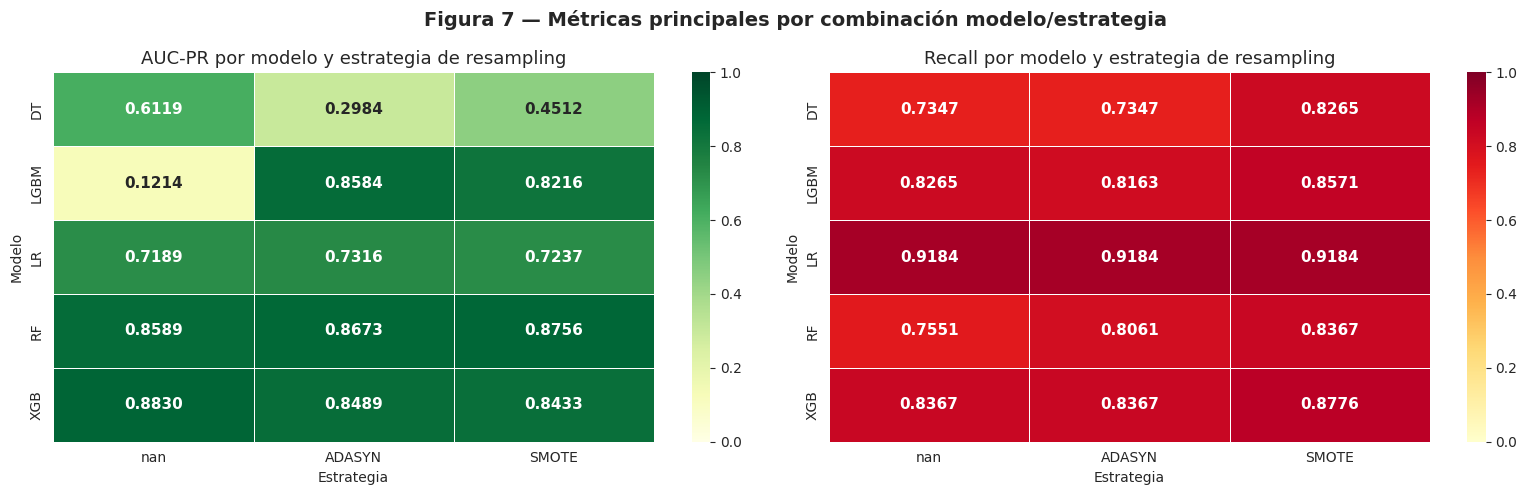

✅ fig07_heatmap_metricas.png guardada


In [9]:
# ── HEATMAP DE AUC-PR ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_aucpr, ax=axes[0], annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('AUC-PR por modelo y estrategia de resampling', fontsize=13)
axes[0].set_ylabel('Modelo')
axes[0].set_xlabel('Estrategia')

sns.heatmap(pivot_recall, ax=axes[1], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('Recall por modelo y estrategia de resampling', fontsize=13)
axes[1].set_ylabel('Modelo')
axes[1].set_xlabel('Estrategia')

plt.suptitle('Figura 7 — Métricas principales por combinación modelo/estrategia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig07_heatmap_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig07_heatmap_metricas.png guardada")


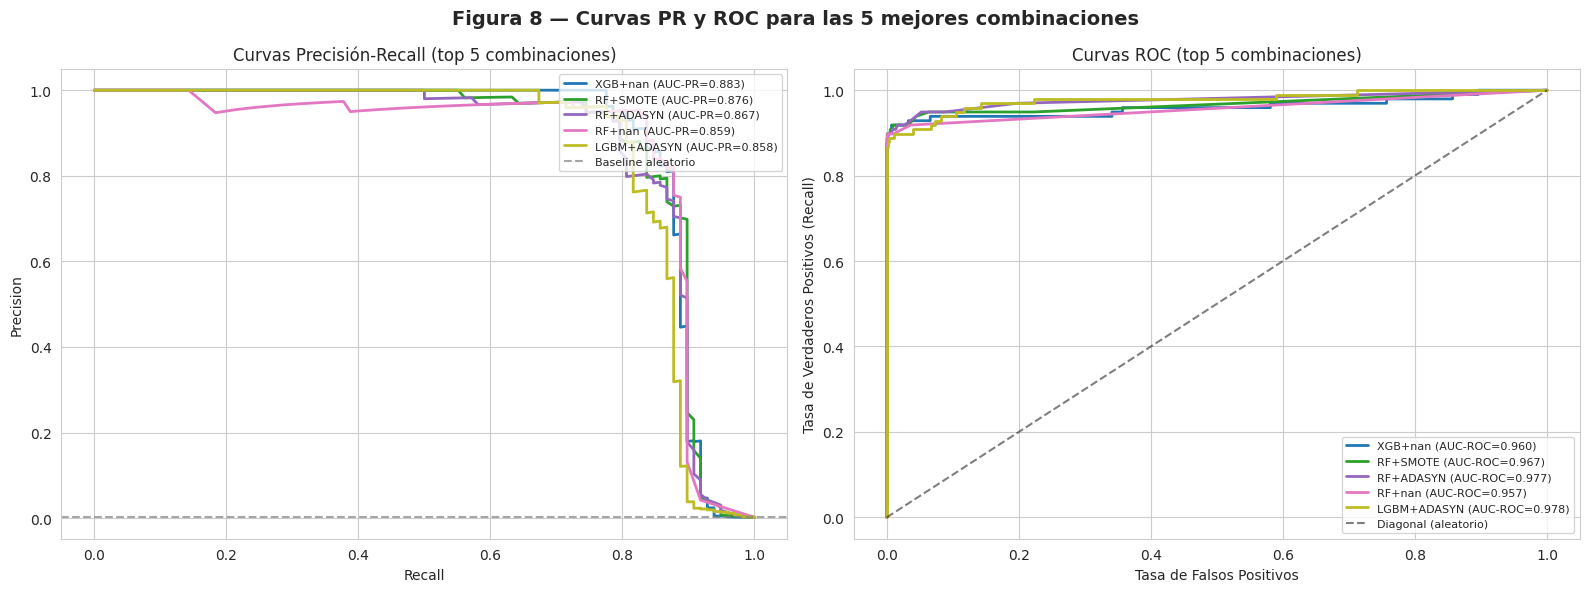

✅ fig08_curvas_pr_roc.png guardada


In [12]:
# ── CURVAS PR Y ROC PARA LOS MEJORES MODELOS ─────────────────────────────
# Seleccionar top 5 combinaciones por AUC-PR
top5 = results_df.nlargest(5, 'AUC_PR')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 0.8, len(top5)))

for i, (_, row) in enumerate(top5.iterrows()):
    combo_key = f"{row['Modelo']}_{row['Estrategia']}"
    model = joblib.load(f"resultados/model_{combo_key}.pkl")
    y_proba = model.predict_proba(X_test)[:, 1]
    label = f"{row['Modelo']}+{row['Estrategia']} (AUC-PR={row['AUC_PR']:.3f})"

    # Curva PR
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[0].plot(rec, prec, color=colors[i], linewidth=2, label=label)

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color=colors[i], linewidth=2,
                 label=f"{row['Modelo']}+{row['Estrategia']} (AUC-ROC={row['AUC_ROC']:.3f})")

axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.7, label='Baseline aleatorio')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curvas Precisión-Recall (top 5 combinaciones)')
axes[0].legend(fontsize=8, loc='upper right')

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Diagonal (aleatorio)')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curvas ROC (top 5 combinaciones)')
axes[1].legend(fontsize=8)

plt.suptitle('Figura 8 — Curvas PR y ROC para las 5 mejores combinaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig08_curvas_pr_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig08_curvas_pr_roc.png guardada")


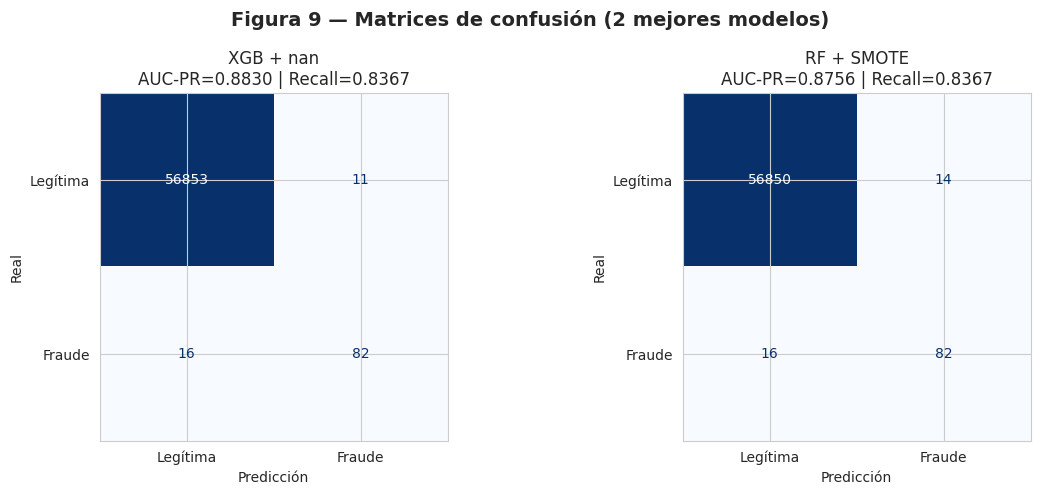

✅ fig09_matrices_confusion.png guardada


In [13]:
# ── MATRICES DE CONFUSIÓN (TOP 2) ────────────────────────────────────────
top2 = results_df.nlargest(2, 'AUC_PR')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (_, row) in enumerate(top2.iterrows()):
    combo_key = f"{row['Modelo']}_{row['Estrategia']}"
    model = joblib.load(f"resultados/model_{combo_key}.pkl")
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítima','Fraude'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{row['Modelo']} + {row['Estrategia']}\nAUC-PR={row['AUC_PR']:.4f} | Recall={row['Recall']:.4f}")
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Figura 9 — Matrices de confusión (2 mejores modelos)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig09_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig09_matrices_confusion.png guardada")


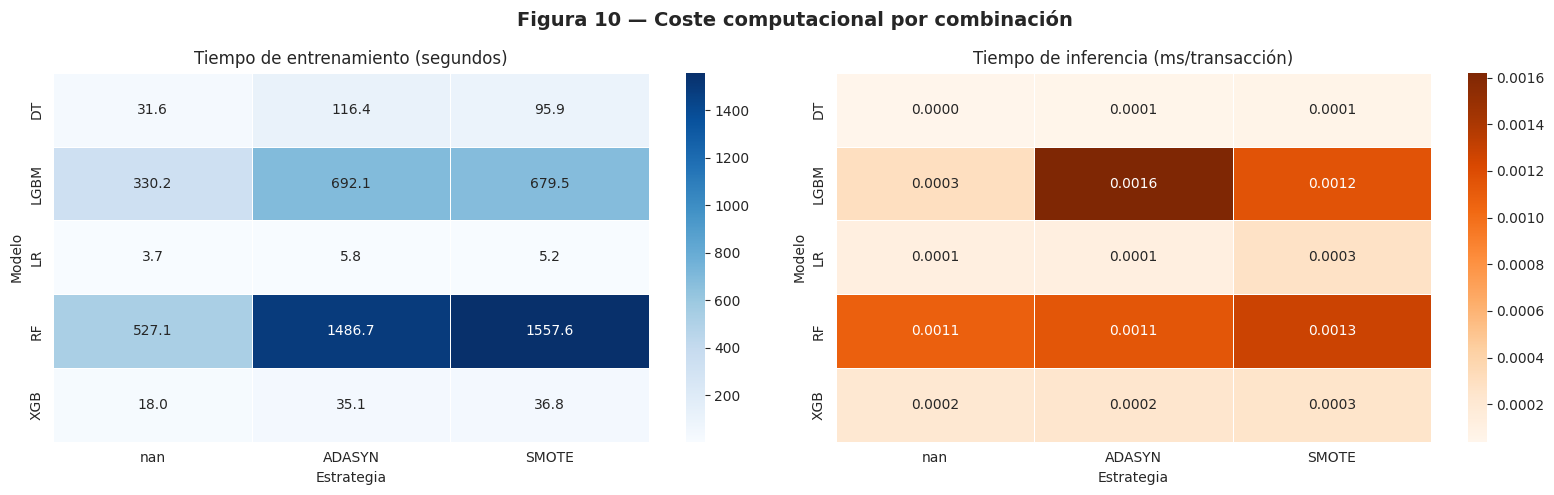

✅ fig10_coste_computacional.png guardada


In [14]:
# ── ANÁLISIS DE COSTE COMPUTACIONAL ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tiempo de entrenamiento
pivot_ttrain = results_df.pivot(index='Modelo', columns='Estrategia', values='T_train_s')
pivot_tinfer = results_df.pivot(index='Modelo', columns='Estrategia', values='T_infer_ms_tx')

sns.heatmap(pivot_ttrain, ax=axes[0], annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Tiempo de entrenamiento (segundos)')

sns.heatmap(pivot_tinfer, ax=axes[1], annot=True, fmt='.4f', cmap='Oranges',
            linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Tiempo de inferencia (ms/transacción)')

plt.suptitle('Figura 10 — Coste computacional por combinación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig10_coste_computacional.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig10_coste_computacional.png guardada")


In [15]:
# ── RESUMEN FINAL ─────────────────────────────────────────────────────────
print("=" * 65)
print("RESUMEN NOTEBOOK 03 — Evaluación sobre dataset ULB")
print("=" * 65)
print()
print("Mejores combinaciones por AUC-PR:")
print(results_df[['Modelo','Estrategia','AUC_PR','Recall','F1','T_train_s']]
      .sort_values('AUC_PR', ascending=False)
      .head(5)
      .to_string(index=False))
print()
print("Archivos generados:")
for f in sorted(os.listdir('resultados')):
    print(f"  ✅ resultados/{f}")
print()
print("➡️  Siguiente paso: ejecutar notebook_04_SHAP.ipynb")
print("    (Necesitas saber cuáles son los 2 mejores modelos de esta tabla)")


RESUMEN NOTEBOOK 03 — Evaluación sobre dataset ULB

Mejores combinaciones por AUC-PR:
Modelo Estrategia  AUC_PR  Recall     F1  T_train_s
   XGB        NaN  0.8830  0.8367 0.8586     18.034
    RF      SMOTE  0.8756  0.8367 0.8454   1557.634
    RF     ADASYN  0.8673  0.8061 0.8229   1486.732
    RF        NaN  0.8589  0.7551 0.8457    527.110
  LGBM     ADASYN  0.8584  0.8163 0.8040    692.073

Archivos generados:
  ✅ resultados/fig07_heatmap_metricas.png
  ✅ resultados/fig08_curvas_pr_roc.png
  ✅ resultados/fig09_matrices_confusion.png
  ✅ resultados/fig10_coste_computacional.png
  ✅ resultados/model_DT_ADASYN.pkl
  ✅ resultados/model_DT_None.pkl
  ✅ resultados/model_DT_SMOTE.pkl
  ✅ resultados/model_DT_nan.pkl
  ✅ resultados/model_LGBM_ADASYN.pkl
  ✅ resultados/model_LGBM_None.pkl
  ✅ resultados/model_LGBM_SMOTE.pkl
  ✅ resultados/model_LGBM_nan.pkl
  ✅ resultados/model_LR_ADASYN.pkl
  ✅ resultados/model_LR_None.pkl
  ✅ resultados/model_LR_SMOTE.pkl
  ✅ resultados/model_LR_nan.pkl
 